In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/credit_risk_dataset.csv')
print("done")
df.head()

done


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [67]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [68]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [69]:
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 80]
print(df.describe())

         person_age  person_income  person_emp_length     loan_amnt  \
count  31679.000000   3.167900e+04       31679.000000  31679.000000   
mean      27.730673   6.649010e+04           4.782064   9659.962436   
std        6.213427   5.276879e+04           4.034948   6334.360554   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.936600e+04           2.000000   5000.000000   
50%       26.000000   5.600000e+04           4.000000   8000.000000   
75%       30.000000   8.000000e+04           7.000000  12500.000000   
max       94.000000   2.039784e+06          41.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   28632.000000  31679.000000         31679.000000   
mean       11.039701      0.215442             0.169610   
std         3.229409      0.411135             0.106269   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

In [70]:
#imputation
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

/tmp/ipykernel_1841/124931513.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
/tmp/ipykernel_1841/124931513.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [71]:
#encoding
df = pd.get_dummies(df, drop_first=True)
df.head(30)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False
6,26,77100,8.0,35000,12.42,1,0.45,3,False,False,...,False,False,False,True,False,False,False,False,False,False
7,24,78956,5.0,35000,11.11,1,0.44,4,False,False,...,True,False,False,True,False,False,False,False,False,False
8,24,83000,8.0,35000,8.90,1,0.42,2,False,False,...,False,True,False,False,False,False,False,False,False,False
9,21,10000,6.0,1600,14.74,1,0.16,3,False,True,...,False,False,True,False,False,True,False,False,False,False
10,22,85000,6.0,35000,10.37,1,0.41,4,False,False,...,False,False,True,True,False,False,False,False,False,False


In [72]:
from sklearn.model_selection import train_test_split
from sklearn .ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

X = df.drop('loan_status', axis=1)
y = df['loan_status']
df.drop('loan_status', axis=1)
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [74]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.93


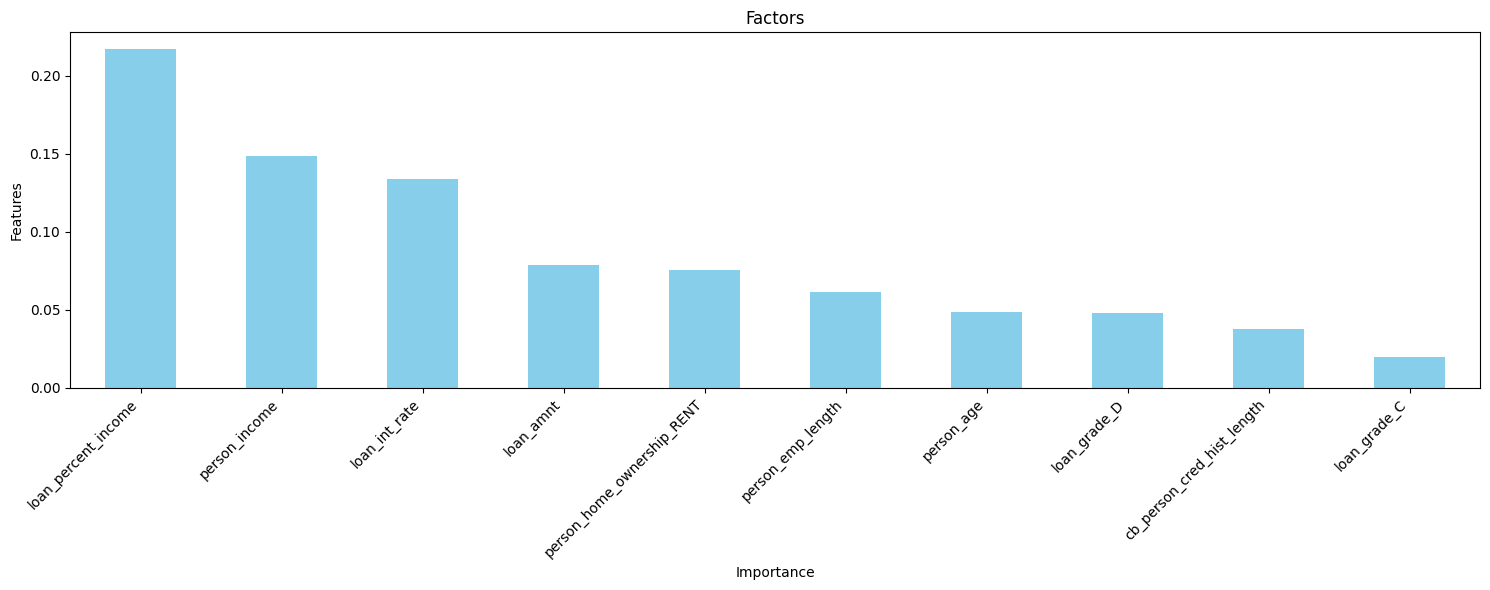

In [75]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(15, 6))
feature_importances.nlargest(10).plot(kind='bar', color='skyblue')
plt.title('Factors')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [76]:
#Logistic regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train) #trainig the model
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8483270202020202


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression After Scaling:", accuracy_score(y_test, y_pred_log))

Logistic Regression After Scaling: 0.8652146464646465


In [78]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)#used x model already trained
y_pred_knn = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8923611111111112


In [79]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9308712121212122


In [80]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
ann.fit(X_train_scaled, y_train)
y_pred_ann = ann.predict(X_test_scaled)
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))

ANN Accuracy: 0.915719696969697


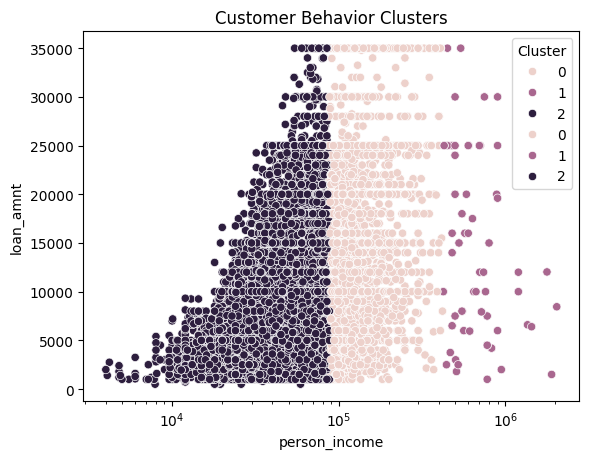

In [81]:
from sklearn.cluster import KMeans
import seaborn as sns

# 1. بنختار الأعمدة الرقمية بس للـ Clustering
df_numerical = df.select_dtypes(include=['int64', 'float64'])

# 2. بنعمل الـ Clusters (مثلاً 3 مجموعات)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_numerical)

# 3. رسمة التوزيع (تغطي الـ Cluster Analysis)
sns.scatterplot(data=df, x='person_income', y='loan_amnt', hue='Cluster')
plt.title('Customer Behavior Clusters')
sns.scatterplot(data=df, x='person_income', y='loan_amnt', hue='Cluster')
plt.title('Customer Behavior Clusters')
plt.xscale('log')
plt.show()

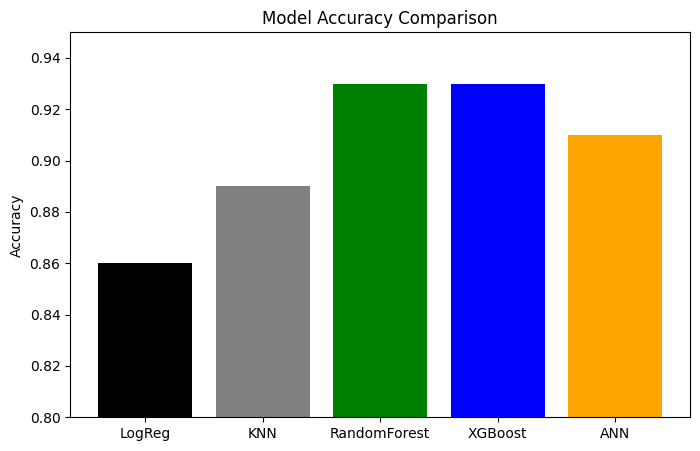

In [82]:
import matplotlib.pyplot as plt

models = ['LogReg', 'KNN', 'RandomForest', 'XGBoost', 'ANN']
scores = [0.86, 0.89, 0.93, 0.93, 0.91]
plt.figure(figsize=(8, 5))
plt.bar(models, scores, color=['Black', 'gray', 'green', 'Blue', 'orange'])
plt.ylim(0.8, 0.95)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

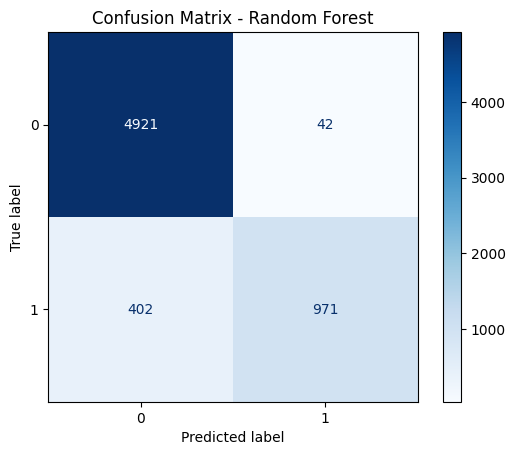

In [83]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# الموديل يتوقع الأول
y_pred = model.predict(X_test)

# نقارن الحقيقة (y_test) بالتوقع (y_pred)
cm = confusion_matrix(y_test, y_pred)

# عرض الرسمة
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [ ]:
# Save the trained model to a file so it can be submitted / reused later
import joblib

joblib.dump(model, 'credit_risk_random_forest_model.pkl')
print("Model saved as credit_risk_random_forest_model.pkl")